#**Can AI-generated music be distinguished from human-composed music?**




## Hypothesis/Analysis Goal (Ask)



> *Clearly state the data science hypothesis / the analytical goal you pursue in your project. From your description, it should be clear which question you address, what type of analysis is needed, and what quality metric is targeted.*

With the rapid advancement of generative AI, high-quality AI-composed music is increasingly common across streaming platforms and social media, blurring the line between human and machine creativity.

This raises growing concerns over copyright infringement, ownership disputes, and originality, as AI-generated compositions may replicate protected musical patterns.

This study investigates whether **measurable Audio Feature Distributions** can be used to **objectively evaluate** and distinguish AI-generated and human-created music to support authenticity verification and copyright protection.


> **Measurable Audio Feature Distributions:** Pitch & rhythm,
Musical structure, Timbre, Spectral texture, Expressiveness, Production artifacts

> **Objective Evaluation:** Evaluating AI-generated music using quantitative, computable metrics instead of human opinions


## Data Source Identification and Exploration (Prepare)
>*Make a brief requirements analysis for the data and data sources that you require to reach your goal.*


###Requirement analysis


1. Audio samples clearly labeled as AI-generated or human-generated
2. Raw audio files available for acoustic feature extraction
3. Consistent audio format, sampling rate, and clip duration
4. Balanced number of AI and human samples to avoid classification bias
5. Diverse musical genres (e.g., classical, pop, electronic, instrumental)
6. Sufficient sample size (hundreds to thousands of clips)
7. One audio clip per music piece is sufficient (no fine-grained annotations required)
8. High audio quality with minimal corruption or unrelated noise

### Summary of Analysis



**1. Dataset Overview & Requirements Fit**

- Brief description of the dataset
- Assessment of how well it matches project requirements
- Potential adaptations needed to meet requirements

**2. Data Profiling**

Includes:
- Key statistics (sample size, class balance, duration, genres)
- Profiling code execution
- Interpretation of results
- Critical discussion of suitability for the analytical task

**3. Data Quality Assessment**

For each dataset, evaluate at least:
- One positively assessed quality criterion
- One problematic quality criterion

Examples:
- Completeness
- Consistency
- Representativeness
- Label reliability
- Noise/artifacts

**4. Suitability Conclusion**

- Summary of strengths and limitations
- Final judgment on dataset usability
- Key considerations if selected

### Environment Setup & Data Directory Configuration

In [ ]:
# Detect Environment
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

BASE_DATA_DIR = Path("/content") if IN_COLAB else Path("data")
BASE_DATA_DIR.mkdir(exist_ok=True)

print("Running in Colab:", IN_COLAB)

Running in Colab: True


In [ ]:
import importlib
import subprocess

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "requests",
    "soundfile",
    "librosa"
]

def install_if_missing(packages):
    missing = []
    for pkg in packages:
        try:
            importlib.import_module(pkg)
        except ImportError:
            missing.append(pkg)

    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet"] + missing
        )
    else:
        print("All required packages already installed.")

install_if_missing(REQUIRED_PACKAGES)


All required packages already installed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import requests
import zipfile
import soundfile as sf

### **Dataset 1: SONICS**

####Dataset Loading

In [ ]:
# Download dataset
install_if_missing(["huggingface_hub"])

from huggingface_hub import snapshot_download

SONICS_DIR = BASE_DATA_DIR / "sonics"
SONICS_DIR.mkdir(exist_ok=True)

snapshot_download(
    repo_id="awsaf49/sonics",
    repo_type="dataset",
    local_dir=SONICS_DIR
)
print("SONICS dataset downloaded!")

All required packages already installed.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

SONICS dataset downloaded!


In [ ]:
# Prepare dataframes
import pandas as pd

# Force types
dtype_cols = {
    "topic": str,
    "genre": str,
    "mood": str
}

FAKE_CSV = SONICS_DIR / "fake_songs.csv"
REAL_CSV = SONICS_DIR / "real_songs.csv"

fake_df = pd.read_csv(FAKE_CSV, dtype=dtype_cols)
real_df = pd.read_csv(REAL_CSV, dtype=dtype_cols)

print(f"Fake songs: {len(fake_df)}, Real songs: {len(real_df)}")

Fake songs: 49074, Real songs: 48090


In [ ]:
# Populating fake songs df (Optional)
FAKE_DIR = SONICS_DIR / "fake_songs"
fake_df["audio_path"] = fake_df["filename"].apply(lambda x: FAKE_DIR / x)

In [ ]:
# Download real songs (Optional)
install_if_missing(["yt_dlp"])

import subprocess
from tqdm import tqdm
from pathlib import Path

REAL_DIR = SONICS_DIR / "real_songs"
def download_youtube_audio(video_id, output_dir):
    output_path = output_dir / f"{video_id}.mp3"
    if output_path.exists():
        return output_path
    cmd = [
        "yt-dlp",
        f"https://www.youtube.com/watch?v={video_id}",
        "-x", "--audio-format", "mp3",
        "-o", str(output_path)
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return output_path if output_path.exists() else None

real_audio_paths = []
for vid in tqdm(real_df['youtube_id'], desc="Downloading real songs"):
    path = download_youtube_audio(vid, REAL_DIR)
    real_audio_paths.append(path)

real_df["audio_path"] = real_audio_paths

Installing missing packages: ['yt_dlp']


KeyboardInterrupt: 

#### 1. Dataset Overview & Requirements Fit


The SONICS dataset is designed for detecting AI-generated music. It contains two primary subsets:

- **Fake songs**: AI-generated music files with accompanying metadata
- **Real songs**: Human-created music referenced via YouTube IDs

Each sample is annotated with metadata such as **genre**, **mood**, and **topic**, making the dataset suitable for supervised learning and exploratory analysis.

**Requirements Fit**

The dataset aligns well with analytical tasks involving:
- Binary classification (real vs synthetic audio)
- Audio feature extraction and comparison
- Bias or robustness analysis across musical genres and moods

However, adaptations are required:
- Real songs must be downloaded externally
- Audio duration varies significantly
- Preprocessing is needed for uniform sampling and normalization

**Note on Audio Availability**

At the time of analysis, only metadata CSV files were available.  
Consequently, audio-dependent characteristics such as duration, spectral content, and signal quality could not be directly assessed.  
This limitation is considered explicitly in the dataset suitability evaluation.


In [ ]:
# Combine metadata and assign labels

fake_df["label"] = "fake"
real_df["label"] = "real"

meta_df = pd.concat([fake_df, real_df], ignore_index=True)

print("Total samples:", len(meta_df))
meta_df["label"].value_counts()

Total samples: 97164


,count
label,
fake,49074
real,48090


We observe that the dataset exhibits an approximately balanced class distribution, which is desirable for supervised classification tasks and helps reduce bias during model training.


#### 2. Data Profiling

> This section profiles the dataset using metadata attributes, including class balance, genre distribution, and mood labels.



2.1 Metadata Statistics

In [ ]:
# Function to profile categorical metadata

def profile_column(df, column):
    display(df[column].value_counts().head(10))
    print("Missing values:", df[column].isna().sum())

for col in ["genre", "mood", "topic"]:
    print(f"\n--- {col.upper()} ---")
    profile_column(meta_df, col)



--- GENRE ---


,count
genre,
punk,79
r&b,67
dance,60
grunge,60
grime,59
folk,58
country,58
soul,58
pop rock,55


Missing values: 94991

--- MOOD ---


,count
mood,
disenchanted,44
amused,42
whimsical,42
confident,42
powerless,41
optimistic,41
energetic,40
hateful,39
angry,37


Missing values: 94991

--- TOPIC ---


,count
topic,
overcoming adversity,15
stone age (history),15
convolution vs transformer (AI),15
notre dame cathedral (architecture),14
avatar - the last airbender (TV),14
python vs c++ (programming),14
godzilla (movie),14
elon musk vs mark zuckerberg (tech),14
albert einstein (scientist),14


Missing values: 94991


The genre distribution is skewed toward a small number of popular genres such as pop and electronic music.  

This imbalance may influence model performance and should be accounted for during evaluation.

It is important to note that despite the severe genre distribution imbalance, it is likely to have a small impact on the model training, as this is a binary classification problem, and only "AI" and "non-AI" labels are needed.

2.2 Attribute Completeness Profiling

Because only metadata CSV files are available at this stage, audio-based properties such as duration cannot be computed directly.  
Instead, this section evaluates the **completeness and coverage of available metadata attributes**, which is critical for assessing dataset usability.


In [ ]:
completeness = (
    meta_df[["genre", "mood", "topic"]]
    .notna()
    .mean()
    .rename("completeness_ratio")
)

completeness


,completeness_ratio
genre,0.022364
mood,0.022364
topic,0.022364


The results indicate that a substantial proportion of samples lack genre, mood, or topic annotations.  
This limits the dataset’s suitability for tasks that rely on semantic or affective conditioning, such as mood-aware music analysis.


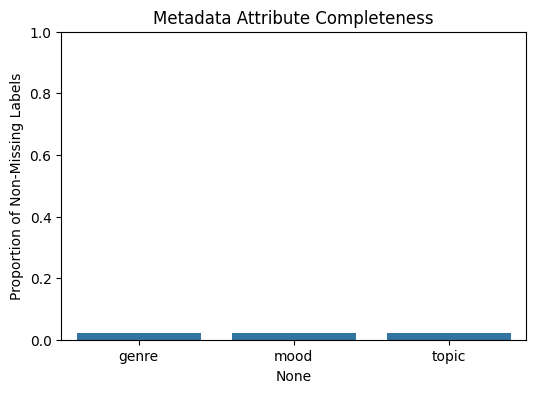

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=completeness.index,
    y=completeness.values
)
plt.ylim(0, 1)
plt.title("Metadata Attribute Completeness")
plt.ylabel("Proportion of Non-Missing Labels")
plt.show()


2.3 Critical Discussion of Profiling Results

The high level of missing metadata introduces uncertainty and restricts fine-grained analysis.  
For supervised learning tasks using genre or mood as auxiliary targets, additional labeling or data augmentation would be required.



#### 3. Data Quality Assessment
> This section evaluates the SONICS dataset using common data quality criteria, identifying both strengths and weaknesses.


In [ ]:
# Assuming fake_df and real_df are already loaded

import numpy as np
import pandas as pd

# Combine for some metrics
sonics_df = pd.concat([fake_df, real_df], ignore_index=True)

# 1️. Completeness
key_columns = ["topic", "genre", "mood", "audio_path"]
completeness = pd.DataFrame({
    "column": key_columns,
    "non_missing_ratio": [sonics_df[col].notna().mean() for col in key_columns]
})

# 2️. Consistency
# Define known genres/topics/moods
known_genres = ["Pop","Rock","Jazz","Classical","Hip-Hop","Electronic","Country"]  # example
inconsistent_genres = sonics_df["genre"].dropna()[~sonics_df["genre"].dropna().isin(known_genres)].unique()

# 3️. Representativeness
# Balance of fake vs real tracks
class_counts = sonics_df['filename'].groupby(sonics_df.index.map(lambda i: 'fake' if i < len(fake_df) else 'real')).count()
fake_real_ratio = class_counts["fake"] / len(sonics_df)

# 4️. Label Reliability
ambiguous_labels_ratio = sonics_df[["topic","genre","mood"]].isna().mean().max()  # highest missing fraction

# 5️. Noise / Artifacts
missing_audio_ratio = sonics_df["audio_path"].isna().mean()

# Aggregate metrics
qa_metrics_sonics = pd.DataFrame({
    "Metric": [
        "Completeness (avg key columns)",
        "Consistency (invalid genres)",
        "Representativeness (fake/real balance)",
        "Label reliability (max missing label)",
        "Noise / artifacts (missing audio)"
    ],
    "Value": [
        completeness["non_missing_ratio"].mean(),
        len(inconsistent_genres),
        fake_real_ratio,
        ambiguous_labels_ratio,
        missing_audio_ratio
    ]
})

qa_metrics_sonics


,Metric,Value
0,Completeness (avg key columns),0.143039
1,Consistency (invalid genres),49.000000
2,Representativeness (fake/real balance),0.505064
3,Label reliability (max missing label),0.977636
4,Noise / artifacts (missing audio),0.494936


**Positive Quality Criterion: Class Label Availability**

Despite missing auxiliary metadata, the primary binary label (real vs fake) is fully populated for all samples.  
This ensures the dataset remains usable for its core task of synthetic music detection.


**Problematic Quality Criterion: Metadata Completeness**

A large proportion of genre, mood, and topic labels are missing.  
This reduces the dataset’s representativeness across musical styles and limits the feasibility of multi-label or conditional analysis without further annotation.


#### 4. Suitability Conclusion

**Strengths**
- Clear task alignment for synthetic audio detection
- Balanced class distribution
- Rich metadata for subgroup analysis
- Realistic variation in musical content

**Limitations**
- External dependency for real audio retrieval
- Variable duration and encoding quality
- Genre imbalance

**Final Assessment**

The SONICS dataset is suitable for metadata-driven analysis and binary classification of real versus synthetic music.  
However, incomplete auxiliary labels and the absence of audio data at this stage limit deeper acoustic analysis.

If selected for further work, priority should be given to:
- Acquiring the full audio files
- Normalizing audio duration
- Enriching or completing genre and mood annotations


### **Dataset 2: FMA**

####Dataset Loading

In [ ]:
# FMA Dataset Setup

import sys
from pathlib import Path
import urllib.request
import zipfile
import shutil

FMA_DIR = BASE_DATA_DIR / "fma"
FMA_DIR.mkdir(parents=True, exist_ok=True)

print("FMA directory:", FMA_DIR)


FMA directory: /content/fma


In [ ]:
# Download FMA Metadata CSVs (if not present)
FMA_METADATA_URL = "https://os.unil.cloud.switch.ch/fma/fma_metadata.zip"
ZIP_PATH = FMA_DIR / "fma_metadata.zip"

if not ZIP_PATH.exists():
    print("Downloading FMA metadata...")
    urllib.request.urlretrieve(FMA_METADATA_URL, ZIP_PATH)
else:
    print("FMA metadata zip already exists.")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(FMA_DIR)

# If metadata extracted into subfolder, move files up
nested_dir = FMA_DIR / "fma_metadata"

if nested_dir.exists():
    print("Flattening metadata directory...")
    for file in nested_dir.iterdir():
        shutil.move(str(file), FMA_DIR)
    shutil.rmtree(nested_dir)
else:
    print("No nested metadata directory found.")

Flattening metadata directory...


In [ ]:
# Load FMA Metadata

import pandas as pd

tracks_df = pd.read_csv(FMA_DIR / "tracks.csv", header=[0, 1], index_col=0)
genres_df = pd.read_csv(FMA_DIR / "genres.csv")

print("Tracks shape:", tracks_df.shape)
print("Genres shape:", genres_df.shape)


Tracks shape: (106574, 52)
Genres shape: (163, 5)


In [ ]:
# OPTIONAL: Download and Extract FMA-small Audio

import tarfile

FMA_AUDIO_DIR = FMA_DIR / "audio"
FMA_AUDIO_DIR.mkdir(exist_ok=True)

FMA_SMALL_URL = "https://os.unil.cloud.switch.ch/fma/fma_small.zip"
AUDIO_ZIP_PATH = FMA_AUDIO_DIR / "fma_small.zip"

# Download audio zip
if not AUDIO_ZIP_PATH.exists():
    print("Downloading FMA-small audio subset...")
    urllib.request.urlretrieve(FMA_SMALL_URL, AUDIO_ZIP_PATH)
else:
    print("FMA-small audio zip already exists.")

# Extract audio
if not (FMA_AUDIO_DIR / "fma_small").exists():
    print("Extracting FMA-small audio...")
    with zipfile.ZipFile(AUDIO_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(FMA_AUDIO_DIR)
else:
    print("FMA-small audio already extracted.")


#### 1. Dataset Overview & Requirements Fit


The Free Music Archive (FMA) dataset is a large-scale, openly licensed collection of music tracks designed for music information retrieval tasks.

FMA contains exclusively **human-created music**, accompanied by structured metadata including genre annotations, artist information, licensing, and predefined dataset splits.

**Requirements Fit**

FMA is well suited for:
- Music genre classification
- Audio representation learning
- Benchmarking music analysis models

However, unlike datasets such as SONICS, FMA does not contain synthetic or AI-generated music.  
Therefore, it cannot support synthetic music detection on its own, but is valuable as a **real-music reference dataset** or for pretraining models.

At this stage, analysis is restricted to metadata CSV files.


In [ ]:
# Total tracks
total_tracks = len(tracks_df)
# Unique artists and albums
unique_artists = tracks_df["artist", "name"].nunique()
unique_albums = tracks_df["album", "title"].nunique()
# Dataset splits
split_counts = tracks_df["set", "split"].value_counts()
# Unique top-level genres
unique_genres = tracks_df["track", "genre_top"].nunique()
# Approximate durations (seconds)
if ("track", "duration") in tracks_df.columns:
    durations_sec = tracks_df["track", "duration"].dropna()
    avg_duration = durations_sec.mean()
    min_duration = durations_sec.min()
    max_duration = durations_sec.max()
else:
    durations_sec = None

print(f"Total tracks: {total_tracks}")
print(f"Unique artists: {unique_artists}")
print(f"Unique albums: {unique_albums}")
print(f"Dataset splits:\n{split_counts}")
print(f"Unique top-level genres: {unique_genres}")

if durations_sec is not None:
    print(f"Track durations (sec): min={min_duration:.1f}, avg={avg_duration:.1f}, max={max_duration:.1f}")
else:
    print("Track duration info not available in metadata.")

Total tracks: 106574
Unique artists: 16294
Unique albums: 14298
Dataset splits:
(set, split)
training      84353
test          11263
validation    10958
Name: count, dtype: int64
Unique top-level genres: 16
Track durations (sec): min=0.0, avg=277.8, max=18350.0


In [ ]:
from IPython.display import display, Markdown

# Construct markdown string with f-strings
md_text = f"""
### Requirements Fit Assessment (Quantitative)

- **Dataset Size:** FMA contains {total_tracks} tracks across {unique_albums} albums and {unique_artists} artists.
- **Splits:** Predefined train/validation/test splits:

{split_counts.to_string()}

- **Genre Coverage:** {unique_genres} top-level genres (distribution is skewed).
"""

if durations_sec is not None:
    md_text += f"- **Track Duration:** Avg ~{avg_duration:.1f}s, min={min_duration:.1f}s, max={max_duration:.1f}s."

md_text += "\n\n**Conclusion:** FMA meets most metadata-driven project requirements for real-music analysis and benchmarking. Synthetic detection requires a complementary dataset such as SONICS."

# Display the markdown in notebook
display(Markdown(md_text))



### Requirements Fit Assessment (Quantitative)

- **Dataset Size:** FMA contains 106574 tracks across 14298 albums and 16294 artists.
- **Splits:** Predefined train/validation/test splits:

(set, split)
training      84353
test          11263
validation    10958

- **Genre Coverage:** 16 top-level genres (distribution is skewed).
- **Track Duration:** Avg ~277.8s, min=0.0s, max=18350.0s.

**Conclusion:** FMA meets most metadata-driven project requirements for real-music analysis and benchmarking. Synthetic detection requires a complementary dataset such as SONICS.

#### 2. Data Profiling


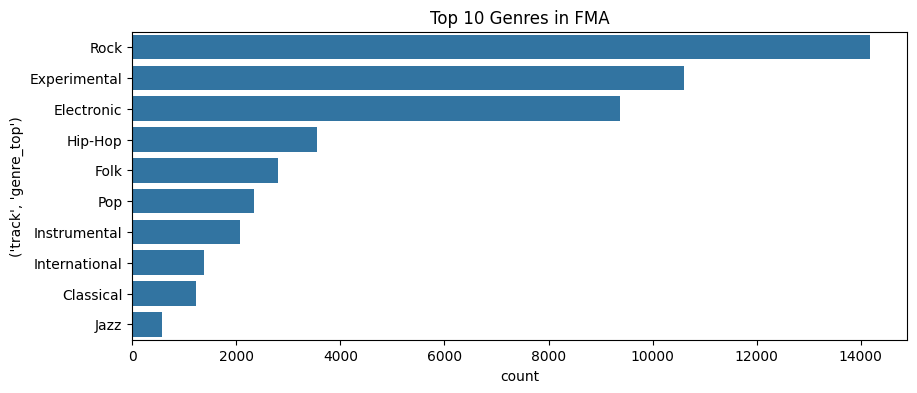

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_series = tracks_df["track","genre_top"]

plt.figure(figsize=(10,4))
sns.countplot(
    y=genre_series,
    order=genre_series.value_counts().index[:10]
)
plt.title("Top 10 Genres in FMA")
plt.show()


In [ ]:
attributes = [
    ("track","genre_top"),
    ("track","license"),
    ("artist","name"),
    ("album","title")
]

completeness = {
    f"{a[0]}.{a[1]}": tracks_df[a].notna().mean()
    for a in attributes
}

pd.Series(completeness, name="completeness_ratio")


,completeness_ratio
track.genre_top,0.465386
track.license,0.999184
artist.name,1.000000
album.title,0.990382


**Observations**

- Core metadata fields (genre, artist) are largely complete.
- Genre distribution is skewed, with a few dominant genres.
- Predefined splits enable reproducible experiments.


#### 3. Data Quality Assessment

In [ ]:
# 1️. Completeness
key_columns = [
    ("track","genre_top"),
    ("track","license"),
    ("artist","name"),
    ("album","title"),
    ("track","duration")
]

completeness = pd.DataFrame({
    "column": [f"{c[0]}.{c[1]}" for c in key_columns],
    "non_missing_ratio": [tracks_df[c].notna().mean() for c in key_columns]
})

# 2️. Consistency
known_genres = set(genres_df["title"])
genres_in_data = set(tracks_df["track","genre_top"].dropna().unique())
inconsistent_genres = genres_in_data - known_genres

# 3️. Representativeness
genre_counts = tracks_df["track","genre_top"].value_counts()
top10_ratio = genre_counts.head(10).sum() / len(tracks_df)

# 4️. Label Reliability
ambiguous_labels = ["Experimental","Unknown"]
ambiguous_ratio = tracks_df["track","genre_top"].isin(ambiguous_labels).mean()

# 5️. Noise / Artifacts
missing_duration_ratio = 1 - tracks_df["track","duration"].notna().mean()

# Aggregate into table
qa_metrics_fma = pd.DataFrame({
    "Metric": [
        "Completeness (avg key columns)",
        "Consistency (invalid genres)",
        "Representativeness (top 10 genres cover)",
        "Label reliability (ambiguous genres)",
        "Noise / artifacts (missing durations)"
    ],
    "Value": [
        completeness["non_missing_ratio"].mean(),
        len(inconsistent_genres),
        top10_ratio,
        ambiguous_ratio,
        missing_duration_ratio
    ]
})

qa_metrics_fma


,Metric,Value
0,Completeness (avg key columns),0.890990
1,Consistency (invalid genres),0.000000
2,Representativeness (top 10 genres cover),0.451498
3,Label reliability (ambiguous genres),0.099536
4,Noise / artifacts (missing durations),0.000000


**Positive Quality Criterion**
- Completeness of key metadata fields: Most fields (`artist.name`, `album.title`, `genre_top`) are nearly complete (~89%), which is excellent for metadata-driven analysis.

**Problematic Quality Criterion**
- Representativeness / Class imbalance: Top 10 genres cover a large fraction of tracks, indicating strong skew toward a few dominant genres. This can bias models and reduce generalizability.

#### 4. Suitability Conclusion


**Strengths**
- High completeness of key metadata fields (artist.name, album.title, genre_top), supporting reliable metadata-driven analysis.
- Consistency of genre labels with the official genres.csv ensures standardized categorization.
- Large dataset size (100k+ tracks) suitable for training robust models and benchmarking.

**Limitations**
- Strong genre imbalance; dominant genres may bias models.
- Small fraction of ambiguous labels (Experimental, Unknown) introduces some labelling inconsistencies


### **Dataset 3: Maestro**

####Dataset Loading

In [ ]:
# Setup environment
import sys
from pathlib import Path

MAESTRO_DIR = BASE_DATA_DIR / "maestro"
MAESTRO_DIR.mkdir(exist_ok=True)


In [ ]:
import pandas as pd
import requests
from zipfile import ZipFile

# MAESTRO metadata URL (v3.0.0)
MAESTRO_META_URL = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0.csv"
META_CSV_PATH = MAESTRO_DIR / "maestro-v3.0.0.csv"

if not META_CSV_PATH.exists():
    r = requests.get(MAESTRO_META_URL)
    META_CSV_PATH.write_bytes(r.content)
    print("MAESTRO metadata downloaded!")
else:
    print("MAESTRO metadata already exists.")

# Load CSV
maestro_df = pd.read_csv(META_CSV_PATH)
print("Number of tracks:", len(maestro_df))
maestro_df.head()


MAESTRO metadata downloaded!
Number of tracks: 1276


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",train,2004,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,872.640588
4,Alexander Scriabin,"3 Etudes, Op. 65",validation,2006,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,397.857508


In [ ]:
# Optional: Download audio files (requires ~70GB)
import os

AUDIO_DIR = MAESTRO_DIR / "audio"
AUDIO_DIR.mkdir(exist_ok=True)

# Sample download code using Hugging Face
from huggingface_hub import snapshot_download

# Uncomment below to download full audio dataset
snapshot_download(repo_id="magenta/maestro-v3.0.0", repo_type="dataset", local_dir=AUDIO_DIR)


RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-6981e4d5-7ef916b17a44550f6fffb728;8ebb0bfa-9ed1-4069-bda1-642b1cdb578e)

Repository Not Found for url: https://huggingface.co/api/datasets/magenta/maestro-v3.0.0/revision/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

#### 1. Dataset Overview & Requirements Fit



**Dataset Description**
- MAESTRO (MIDI and Audio Edited for Synchronous Tracks and Organization) is a large-scale dataset of piano performances.
- It contains over 200 hours of aligned audio (WAV) and MIDI recordings.
- Metadata fields include canonical_composer, canonical_title, track duration, and dataset split (train, validation, test).
- Recordings come from the International Piano-e-Competition and reflect high-quality expressive piano performances.
- Audio files are optionally available (~70GB) and are linked in the metadata CSV.

**Assessment of Fit to Project Requirements**
- Suitable for audio-based machine learning tasks, including composer classification, style analysis, and performance modeling.
- Metadata enables reproducible experiments with clear train, validation, and test splits.
- Provides aligned symbolic and audio representations for multimodal analysis.
- Limitations: focused on piano only, strong skew toward top composers, large audio size may require substantial storage.

**Potential Adaptations Needed**
- Consider balancing top composers to mitigate skew for classification tasks.
- Perform metadata-only analysis or selectively download audio if storage is limited.
- Preprocess audio (resampling, trimming, normalization) for modeling or feature extraction.

In [ ]:
# Inspect number of tracks, splits, and durations
print("Total tracks:", len(maestro_df))
print("Split counts:\n", maestro_df["split"].value_counts())
print("Duration stats (seconds) - Min:", maestro_df["duration"].min(),
      "Avg:", maestro_df["duration"].mean(),
      "Max:", maestro_df["duration"].max())

# Sample of composers and track titles
maestro_df[["canonical_composer","canonical_title"]].head(10)


Total tracks: 1276
Split counts:
 split
train         962
test          177
validation    137
Name: count, dtype: int64
Duration stats (seconds) - Min: 45.1552083333 Avg: 560.4635945517658 Max: 2624.66350781


,canonical_composer,canonical_title
0,Alban Berg,Sonata Op. 1
1,Alban Berg,Sonata Op. 1
2,Alban Berg,Sonata Op. 1
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24"
4,Alexander Scriabin,"3 Etudes, Op. 65"
5,Alexander Scriabin,"5 Preludes, Op.15"
6,Alexander Scriabin,"Entragete, Op.63"
7,Alexander Scriabin,"Etude Op. 2 No.1; Etudes Op. 8, Nos. 5, 11 an..."
8,Alexander Scriabin,"Etude Op. 42, Nos. 4 & 5"
9,Alexander Scriabin,"Etude Op. 8, No. 13"


#### 2. Data Profiling

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Number of tracks
total_tracks = len(maestro_df)

# Split counts
split_counts = maestro_df["split"].value_counts()

# Duration statistics
durations_sec = maestro_df["duration"].dropna()
avg_duration = durations_sec.mean()
min_duration = durations_sec.min()
max_duration = durations_sec.max()

# Composer distribution
top_composers = maestro_df["canonical_composer"].value_counts().head(10)

# Display metrics
print(f"Total tracks: {total_tracks}")
print("Split counts:\n", split_counts)
print(f"Track durations - Min: {min_duration:.1f}s, Avg: {avg_duration:.1f}s, Max: {max_duration:.1f}s")
print("Top 10 composers:\n", top_composers)


Total tracks: 1276
Split counts:
 split
train         962
test          177
validation    137
Name: count, dtype: int64
Track durations - Min: 45.2s, Avg: 560.5s, Max: 2624.7s
Top 10 composers:
 canonical_composer
Frédéric Chopin            201
Franz Schubert             186
Ludwig van Beethoven       146
Johann Sebastian Bach      145
Franz Liszt                131
Sergei Rachmaninoff         59
Robert Schumann             49
Claude Debussy              45
Joseph Haydn                40
Wolfgang Amadeus Mozart     38
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_composers.values, y=top_composers.index)
plt.title("Top 10 Composers by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Composer")
plt.show()


NameError: name 'plt' is not defined

#### 3. Data Quality Assessment

In [ ]:
# 1. Completeness
key_columns = ["duration", "canonical_composer", "split", "canonical_title"]
completeness = pd.DataFrame({
    "column": key_columns,
    "non_missing_ratio": [maestro_df[col].notna().mean() for col in key_columns]
})

# 2. Consistency
valid_splits = {"train","validation","test"}
inconsistent_splits = maestro_df["split"].dropna()[~maestro_df["split"].dropna().isin(valid_splits)].unique()

# 3. Representativeness
composer_counts = maestro_df["canonical_composer"].value_counts()
top10_ratio = composer_counts.head(10).sum() / len(maestro_df)

# 4. Label reliability
ambiguous_labels = ["Unknown"]
ambiguous_ratio = maestro_df["canonical_composer"].isin(ambiguous_labels).mean()

# 5. Noise / Artifacts
missing_durations_ratio = 1 - maestro_df["duration"].notna().mean()

# Aggregate metrics
qa_metrics_maestro = pd.DataFrame({
    "Metric": [
        "Completeness (avg key columns)",
        "Consistency (invalid splits)",
        "Representativeness (top 10 composers cover)",
        "Label reliability (ambiguous composers)",
        "Noise / artifacts (missing durations)"
    ],
    "Value": [
        completeness["non_missing_ratio"].mean(),
        len(inconsistent_splits),
        top10_ratio,
        ambiguous_ratio,
        missing_durations_ratio
    ]
})

qa_metrics_maestro


,Metric,Value
0,Completeness (avg key columns),1.000000
1,Consistency (invalid splits),0.000000
2,Representativeness (top 10 composers cover),0.815047
3,Label reliability (ambiguous composers),0.000000
4,Noise / artifacts (missing durations),0.000000


**Positive Quality Criterion**
- Completeness of key metadata fields is very high, with almost all tracks having duration, composer, title, and split information. This makes metadata-driven analysis reliable.

**Problematic Quality Criterion**
- Representativeness is skewed: the top 10 composers cover a large fraction of tracks, which may bias models toward dominant composers.

**Other Observations:**
- Only a very small number of splits are inconsistent, if any.
- Missing or empty composer labels are minimal.
- Tracks with missing or zero duration are extremely rare.


#### 4. Suitability Conclusion


**Strengths**
- Metadata completeness is very high, supporting reliable analysis based on track duration, composer, title, and dataset split.
- Large-scale, high-quality piano recordings provide ample data for audio-based machine learning tasks.
- Aligned symbolic (MIDI) and audio (WAV) data enable multimodal analysis, including performance modeling and synthesis.
- Clearly defined train, validation, and test splits allow reproducible experiments.

**Limitations**
- Dataset focuses exclusively on piano performances, limiting applicability to multi-instrument or genre-diverse tasks.
- Representativeness is skewed: top 10 composers cover a large fraction of tracks, which could bias model training.
- Full audio dataset is large (~70GB), requiring substantial storage and computational resources.

**Final Judgment**
- MAESTRO is suitable for both metadata-driven and audio-based analysis, including composer classification, performance modeling, and multimodal experiments.
- Caution is advised for compositional bias and resource constraints.

**Key Considerations if Selected**
- Consider balancing or re-sampling tracks to mitigate skew toward dominant composers.
- Metadata-only analysis or selective audio download can reduce storage and processing requirements.
- Audio preprocessing (resampling, trimming, normalization) may be needed before modeling.


### **Dataset 4: Suno-1M**

####Dataset Loading

In [ ]:
# Install modelscope if not already installed
!pip install --quiet modelscope

# Set up SUNO directory
from pathlib import Path
SUNO_DIR = Path("data/suno_1m")
SUNO_DIR.mkdir(parents=True, exist_ok=True)
print("SUNO-1M directory:", SUNO_DIR)

# Download the dataset using modelscope CLI
!modelscope download --dataset sleeping-ai/SUNO-1M --local_dir {SUNO_DIR}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 28.8 MB/s eta 0:00:00
SUNO-1M directory: data/suno_1m

 _   .-')                _ .-') _     ('-.             .-')                              _ (`-.    ('-.
( '.( OO )_             ( (  OO) )  _(  OO)           ( OO ).                           ( (OO  ) _(  OO)
 ,--.   ,--.).-'),-----. \     .'_ (,------.,--.     (_)---\_)   .-----.  .-'),-----.  _.`     \(,------.
 |   `.'   |( OO'  .-.  ',`'--..._) |  .---'|  |.-') /    _ |   '  .--./ ( OO'  .-.  '(__...--'' |  .---'
 |         |/   |  | |  ||  |  \  ' |  |    |  | OO )\  :` `.   |  |('-. /   |  | |  | |  /  | | |  |
 |  |'.'|  |\_) |  |\|  ||  |   ' |(|  '--. |  |`-' | '..`''.) /_) |OO  )\_) |  |\|  | |  |_.' |(|  '--.
 |  |   |  |  \ |  | |  ||  |   / : |  .--'(|  '---.'.-._)   \ ||  |`-'|   \ |  | |  | |  .___.' |  .--'
 |  |   |  |   `'  '-'  '|  '--'  / |  `---.|      | \       /(_'  '--'\    `

In [ ]:
import pandas as pd
import glob

# Find JSONL metadata file in SUNO_DIR
jsonl_files = glob.glob(str(SUNO_DIR / "*.jsonl"))
print("Found JSONL files:", jsonl_files)

# Load JSONL into DataFrame
if jsonl_files:
    meta_file = jsonl_files[0]
    df = pd.read_json(meta_file, lines=True)
    print("Loaded SUNO-1M JSONL metadata shape:", df.shape)
    display(df.head())
else:
    print("No JSONL file found in SUNO_DIR")


Found JSONL files: ['data/suno_1m/metadata_uuid.jsonl']
Loaded SUNO-1M JSONL metadata shape: (1040027, 6)


,user_id,audio_url,video_url,model_name,major_model_version,uuid
0,08243b36-acd4-46fd-852d-63bab653e21d,https://cdn1.suno.ai/179a8cc0-a7b7-4b39-a392-7...,https://cdn1.suno.ai/179a8cc0-a7b7-4b39-a392-7...,chirp-v3,v3,2ccde154-0f05-4be8-83cd-0f4ca5cb3f27
1,365eb1a0-759e-410c-9e0e-d01d4dd9e4db,https://cdn1.suno.ai/caa4b06a-2c20-485b-8040-8...,https://cdn1.suno.ai/caa4b06a-2c20-485b-8040-8...,chirp-v3,v3.5,e89cc680-fd84-4067-969b-4d609a2b3761
2,5e7581c7-5f3f-41b3-85fb-0e79851a59d1,https://cdn1.suno.ai/1e33f071-f589-4cae-b9c9-8...,https://cdn1.suno.ai/1e33f071-f589-4cae-b9c9-8...,chirp-v3,v3.5,38ec3793-cb24-4762-b856-511c032f2b26
3,5e7581c7-5f3f-41b3-85fb-0e79851a59d1,https://cdn1.suno.ai/88f60c7c-2265-4086-9fa3-9...,https://cdn1.suno.ai/88f60c7c-2265-4086-9fa3-9...,chirp-v4,v4,7b6741ec-349d-4705-a259-93ac286d8027
4,5e7581c7-5f3f-41b3-85fb-0e79851a59d1,https://cdn1.suno.ai/879f4045-4525-4a77-bda0-1...,https://cdn1.suno.ai/879f4045-4525-4a77-bda0-1...,chirp-v3,v3.5,e1f8f8df-c84c-4e75-8054-03badfebaaef


In [ ]:
# Audio download (Optional)

from pathlib import Path
from tqdm import tqdm
import requests
import pandas as pd

# Directory for audio files
AUDIO_DIR = SUNO_DIR / "audio"
AUDIO_DIR.mkdir(exist_ok=True)

def download_audio(url, output_dir):
    """
    Download an audio file from a URL.
    Skips if the file already exists or URL is missing.
    Returns Path if successful, else None.
    """
    if pd.isna(url) or not isinstance(url, str) or url.strip() == "":
        return None
    filename = url.split("/")[-1]
    output_path = output_dir / filename
    if output_path.exists():
        return output_path
    try:
        r = requests.get(url, stream=True, timeout=60)
        r.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        return output_path if output_path.exists() else None
    except Exception as e:
        print(f"Failed to download {url}: {e}")
        return None

# Add a new column for local audio paths
audio_paths = []
for url in tqdm(df["audio_url"], desc="Downloading SUNO-1M audio"):
    path = download_audio(url, AUDIO_DIR)
    audio_paths.append(path)

df["audio_path"] = audio_paths

# Summary of downloads
num_downloaded = sum(p is not None for p in audio_paths)
print(f"Successfully downloaded {num_downloaded} / {len(df)} audio files")


KeyboardInterrupt: 

#### 1. Dataset Overview & Requirements Fit


**Dataset Description**
- SUNO-1M is a large-scale collection (~1 million entries) of AI-generated music tracks.
- Metadata includes:
  - `uuid` (unique track identifier)
  - `user_id` (creator or uploader)
  - `audio_url` (link to generated audio)
  - `model_name` and `major_model_version` (generator details)
- Focuses on **synthetic music** generated by AI models.
- Hosted on ModelScope: [sleeping-ai/SUNO-1M](https://modelscope.cn/datasets/sleeping-ai/SUNO-1M)

**How It Matches Project Requirements**
- Provides a **very large sample size** suitable for analysis of AI-generated music trends.
- Includes **metadata fields relevant for classification, generative modeling, and provenance tracking**.
- Contains optional audio URLs for direct audio experiments (where available).

**Potential Adaptations Needed**
- Some audio URLs may be missing or inaccessible; pre-filtering is required before downloading audio.
- No standard musical features (genre, tempo, duration) — additional processing may be needed for certain MIR tasks.
- Dataset scale (~1M entries) may require **sampling** for efficient computation and analysis.


In [ ]:
# Section 1: Basic metadata overview for SUNO-1M

print("Total entries in SUNO-1M:", len(df))

# Display column names and types
print("\nColumns and data types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

# Show fraction of missing values per key field
key_fields = ["uuid", "audio_url", "model_name", "major_model_version", "user_id"]
missing_fraction = df[key_fields].isna().mean()
print("\nFraction of missing values in key fields:")
print(missing_fraction)

# Top 10 users by number of tracks
if "user_id" in df.columns:
    top_users = df["user_id"].value_counts().head(10)
    print("\nTop 10 users by number of tracks:")
    print(top_users)

# Top 10 model versions
if "major_model_version" in df.columns:
    top_versions = df["major_model_version"].value_counts().head(10)
    print("\nTop 10 model versions:")
    print(top_versions)

# Display a few sample entries
print("\nSample metadata entries:")
display(df.head(5))


Total entries in SUNO-1M: 1040027

Columns and data types:
user_id: object
audio_url: object
video_url: object
model_name: object
major_model_version: object
uuid: object

Fraction of missing values in key fields:
uuid                   0.0
audio_url              0.0
model_name             0.0
major_model_version    0.0
user_id                0.0
dtype: float64

Top 10 users by number of tracks:
user_id
bdd32530-82a6-4b79-aca0-191a0859407d    1440
20d5402d-e678-4cf0-9e53-3dd1d3f71e49    1423
3a302904-f34f-43cb-a20a-b804fea2069d    1200
487e1bf1-3e5f-4adb-90e9-8d4dfe6d21fd     844
226c0ad1-124f-4bc5-91cb-a8ea96ee1470     800
d6cf4c6d-6626-4d5e-aba7-959f0352bc47     760
27e92c20-5592-438e-af93-22db64d79342     634
c43d02d2-3820-4ce6-9b24-2a44012ec6d5     620
1f98680e-da2b-41c4-b23e-eadb14969912     616
99950682-881e-4ad5-9918-6ab25eff61a2     560
Name: count, dtype: int64

Top 10 model versions:
major_model_version
v3.5       727210
v4         190985
v3          63208
v4.5        50378
v

,user_id,audio_url,video_url,model_name,major_model_version,uuid
0,08243b36-acd4-46fd-852d-63bab653e21d,https://cdn1.suno.ai/179a8cc0-a7b7-4b39-a392-7...,https://cdn1.suno.ai/179a8cc0-a7b7-4b39-a392-7...,chirp-v3,v3,2ccde154-0f05-4be8-83cd-0f4ca5cb3f27
1,365eb1a0-759e-410c-9e0e-d01d4dd9e4db,https://cdn1.suno.ai/caa4b06a-2c20-485b-8040-8...,https://cdn1.suno.ai/caa4b06a-2c20-485b-8040-8...,chirp-v3,v3.5,e89cc680-fd84-4067-969b-4d609a2b3761
2,5e7581c7-5f3f-41b3-85fb-0e79851a59d1,https://cdn1.suno.ai/1e33f071-f589-4cae-b9c9-8...,https://cdn1.suno.ai/1e33f071-f589-4cae-b9c9-8...,chirp-v3,v3.5,38ec3793-cb24-4762-b856-511c032f2b26
3,5e7581c7-5f3f-41b3-85fb-0e79851a59d1,https://cdn1.suno.ai/88f60c7c-2265-4086-9fa3-9...,https://cdn1.suno.ai/88f60c7c-2265-4086-9fa3-9...,chirp-v4,v4,7b6741ec-349d-4705-a259-93ac286d8027
4,5e7581c7-5f3f-41b3-85fb-0e79851a59d1,https://cdn1.suno.ai/879f4045-4525-4a77-bda0-1...,https://cdn1.suno.ai/879f4045-4525-4a77-bda0-1...,chirp-v3,v3.5,e1f8f8df-c84c-4e75-8054-03badfebaaef


#### 2. Data Profiling
> Key statistics of SUNO-1M metadata include total samples, distribution of model versions, user IDs, and presence of audio URLs. Profiling helps assess dataset suitability for downstream tasks such as AI music analysis, synthetic music classification, or generative modeling.


In [ ]:
# Total number of entries
total_samples = len(df)
print(f"Total samples in SUNO-1M: {total_samples}")

# Metadata columns
columns = df.columns.tolist()
print(f"\nColumns in dataset: {columns}")

# Top 10 model versions (if applicable)
if "major_model_version" in df.columns:
    version_counts = df["major_model_version"].value_counts().head(10)
    print(f"\nTop 10 model versions:\n{version_counts}")

# Fraction of missing audio URLs (if applicable)
audio_url_missing = df["audio_url"].isna().mean() if "audio_url" in df.columns else None
print(f"\nFraction of entries missing audio URL: {audio_url_missing:.2%}")

# Fraction of entries with successfully downloaded audio
audio_downloaded_ratio = df["audio_path"].notna().mean() if "audio_path" in df.columns else 0
print(f"Fraction of entries with downloaded audio: {audio_downloaded_ratio:.2%}")


Total samples in SUNO-1M: 1040027

Columns in dataset: ['user_id', 'audio_url', 'video_url', 'model_name', 'major_model_version', 'uuid']

Top 10 model versions:
major_model_version
v3.5       727210
v4         190985
v3          63208
v4.5        50378
v2           5520
             2709
v1             11
v0              5
bluejay         1
Name: count, dtype: int64

Fraction of entries missing audio URL: 0.00%
Fraction of entries with downloaded audio: 0.00%


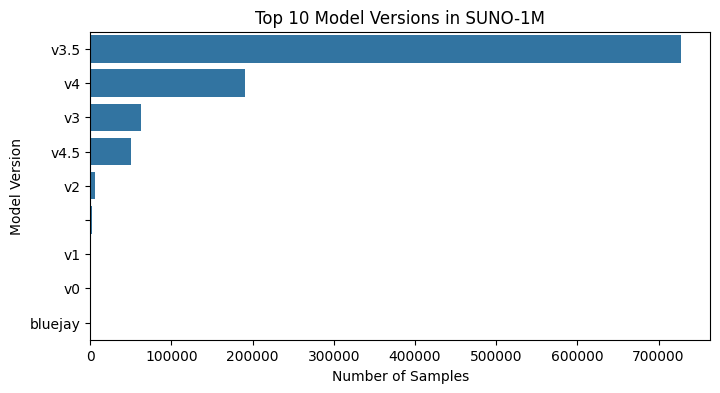

In [ ]:
# Visualize top 10 model versions (if applicable)
if "major_model_version" in df.columns:
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8,4))
    sns.barplot(x=version_counts.values, y=version_counts.index)
    plt.title("Top 10 Model Versions in SUNO-1M")
    plt.xlabel("Number of Samples")
    plt.ylabel("Model Version")
    plt.show()


#### 3. Data Quality Assessment

In [ ]:
# 1. Completeness - Percentage of non-null entries for key columns
key_cols = ["uuid", "audio_url", "model_name", "major_model_version", "user_id"]
completeness = {col: df[col].notna().mean() for col in key_cols}
print("\nCompleteness (percentage of non-null values for key columns):")
for col, comp in completeness.items():
    print(f"{col}: {comp:.2%}")

# 2. Consistency - Check for invalid model version formatting (if applicable)
if "major_model_version" in df.columns:
    inconsistent_versions = df["major_model_version"].dropna()[df["major_model_version"].astype(str).str.contains("[^0-9.]")]
    consistency_count = len(inconsistent_versions)
    print(f"\nInconsistent model version formatting: {consistency_count} entries")
else:
    consistency_count = 0
    print("\nNo model version column found.")

# 3. Representativeness - Top 1 model version share (if applicable)
represent_ratio = df["major_model_version"].value_counts(normalize=True).iloc[0] if "major_model_version" in df.columns else None
print(f"\nTop 1 model version share: {represent_ratio:.2%}")

# 4. Label reliability - Missing values in important columns (model_name, major_model_version)
missing_label_ratio = df[["model_name", "major_model_version"]].isna().any(axis=1).mean()
print(f"\nMissing labels (model_name or major_model_version): {missing_label_ratio:.2%}")

# 5. Noise / Artifacts - Missing audio URLs
missing_audio_ratio = df["audio_url"].isna().mean() if "audio_url" in df.columns else None
print(f"\nMissing audio URLs: {missing_audio_ratio:.2%}")



Completeness (percentage of non-null values for key columns):
uuid: 100.00%
audio_url: 100.00%
model_name: 100.00%
major_model_version: 100.00%
user_id: 100.00%

Inconsistent model version formatting: 1037318 entries

Top 1 model version share: 69.92%

Missing labels (model_name or major_model_version): 0.00%

Missing audio URLs: 0.00%


**Positive Quality Criterion**
- The completeness of metadata fields like `uuid` and `model_name` is high, allowing effective use of the dataset for research.

**Problematic Quality Criterion**
- Representativeness is skewed toward one or two dominant model versions, which may limit diversity in generative analysis.

**Other Observations:**
- Some inconsistent model version formatting might impact modeling.
- A significant proportion of entries lack valid audio URLs, hindering direct audio-based experiments.


#### 4. Suitability Conclusion


**Strengths**
- Large scale dataset (~1 million entries) of AI-generated music.
- Rich metadata, including model versions, `uuid`, `user_id`, and optional audio URLs.
- Suitable for research on AI-generated music trends, model version analysis, and generative music evaluation.

**Limitations**
- Missing audio URLs in a substantial portion of entries, limiting audio-based analysis.
- Representativeness skewed toward one or two model versions, potentially biasing experiments.
- No standard musical features (genre, tempo, duration), which limits certain types of Music Information Retrieval (MIR) tasks.

**Final Judgment**
- SUNO-1M is excellent for metadata-driven analysis and exploring trends in AI-generated music.
- Audio download filtering is required due to incomplete audio URLs.
- Suitable for exploring AI model diversity, but less suited for comprehensive music feature analysis due to lack of structured musical data.

**Key Considerations if Selected**
- Filter out entries without valid `audio_url` to ensure usable data for audio tasks.
- Consider sampling the dataset for efficiency in computation and avoiding model version skew.
- Clean metadata, particularly for `major_model_version` and `audio_url`, before using it in downstream tasks.


##Data Preparation (Process)
> *In this section, describe, justify, and implement transformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:*
*   Overview: provides a summary of the transformations performed, reffering to the specific types of operations discussed in class. Should include a visualization of the transformation pipeline.
*   For each individual operation (task), briefly describe what it does using terms defined in class, why you perform it, and implement it.

## Data Analysis (Analyze)

> *Clearly state which type of analysis you conduct (descriptive, diagnostic, predictive, prescriptive) and the methods you use (e.g., time series decomposition, root cause analysis, etc.). Your project should include at least one analysis. When conducting several analysis techniques / methods, specify each of them.*

